# GPS Fleet Ops Agent

A small Router + specialist multi-agent assistant, structured the same way
as `Final_Project_Phase_3_Enkhjargal.ipynb` (Router classifies intent -> a
specialist agent pulls real data -> an LLM formats the answer), but wired to
this repo's mine-fleet GPS pipeline instead of the Peloton CSVs.

**This notebook only reads pre-aggregated CSVs from `data/agent_data/`** —
all the heavy lifting (cleaning, zone-hit joins, DBSCAN clustering) happens
once, offline, in [`fleet_agent/preprocessing.py`](./preprocessing.py). Run that
script first:

```bash
python fleet_agent/preprocessing.py
```

That script is scoped to the **BN sub-fleet and BN zones only** for now. It
writes, under `data/agent_data/`:
- `tracker_list_bn.csv`, `zone_diameter_bn.csv` — static BN reference data
- `daily_<year>-<month>.csv` — one row per **(date, tracker_id)** that month
  (cycle KPIs, fleet-time breakdown, DBSCAN idle share) — `tracker_id="ALL"`
  is the fleet-wide row, every other value is one BN truck
- `routes_<year>-<month>.csv`, `zone_qa_<year>-<month>.csv` — route share and
  zone data-quality flags for that month (fleet-wide, not per-truck)
- `monthly_<year>.csv` — one row per **(month, tracker_id)**, rolled up from
  the daily files

| # | Agent | Primary Responsibility |
|---|---|---|
| 0 | **Router Agent** | Classifies intent, extracts a date/month/year/truck mentioned in the question |
| A | **Cycle & Productivity Agent** | Haul-cycle timing, distance, route-share KPIs — fleet-wide or per truck |
| B | **Idle & Stops Agent** | Fleet-time breakdown, DBSCAN unplanned-idle share — fleet-wide or per truck |
| C | **Route & Zone QA Agent** | Zone-to-zone route share, zone data-quality flags (fleet-wide) |
| D | **Fleet Health Agent** | BN tracker inventory, zone-size sanity stats |
| H | **Human-in-the-Loop** | Escalation when data is missing or the question doesn't fit a specialist |

Requires `OPENAI_API_KEY` in `.env` to run the LLM nodes — without a key the
specialist nodes still return the raw data context, just unformatted.

In [1]:
import sys, os, json, warnings
sys.path.append("..")

from pathlib import Path
import numpy as np
import pandas as pd
from typing import TypedDict, Optional, Dict, Any
from IPython.display import display, Markdown, Image

from dotenv import load_dotenv
load_dotenv("../.env")
warnings.filterwarnings("ignore")

from gps_lib import config
from agent_v2_specialist import fetch_diagnosis, DIAGNOSIS_PROMPT

from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
print("OpenAI key found." if OPENAI_API_KEY else
      "OPENAI_API_KEY not set - add it to .env to run the router/specialist LLM calls.")

OpenAI key found.


### Parameters

`MONTH` is only the fallback used when a question doesn't mention a
date/month/year of its own (the router tries to extract one from the
question text first).

In [2]:
MONTH: Optional[str] = "2025-11"  # e.g. "2025-06" — default period when a question doesn't specify one

## Section 1 — Reading preprocessed agent data

Every function here just reads a small CSV from `data/agent_data/` — no
pandas pipeline, no geopandas, no DBSCAN. If a file is missing it means
`fleet_agent/preprocessing.py` hasn't been run for that period yet.

In [3]:
AGENT_DATA_DIR = Path(config.DATA_DIR) / "agent_data"


def _norm_month(month: str) -> str:
    year, mon = month.split("-")
    return f"{int(year)}-{int(mon):02d}"


def _load_agent_csv(name: str) -> Optional[pd.DataFrame]:
    path = AGENT_DATA_DIR / name
    return pd.read_csv(path) if path.exists() else None


def get_daily(month: str) -> Optional[pd.DataFrame]:
    return _load_agent_csv(f"daily_{_norm_month(month)}.csv")


def get_routes(month: str) -> Optional[pd.DataFrame]:
    return _load_agent_csv(f"routes_{_norm_month(month)}.csv")


def get_zone_qa(month: str) -> Optional[pd.DataFrame]:
    return _load_agent_csv(f"zone_qa_{_norm_month(month)}.csv")


def get_monthly(year: str) -> Optional[pd.DataFrame]:
    return _load_agent_csv(f"monthly_{year}.csv")


def get_tracker_list() -> Optional[pd.DataFrame]:
    return _load_agent_csv("tracker_list_bn.csv")


def get_zone_diameter() -> Optional[pd.DataFrame]:
    return _load_agent_csv("zone_diameter_bn.csv")

## Section 2 — Architecture

Same Router -> specialist -> response shape as the inspiration notebook.
This is a hand-drawn illustration — Section 7 renders the *actual* compiled
graph.

In [4]:
mermaid_diagram = """
```mermaid
graph TD
    U([User / Ops Analyst]) -->|natural language question| RT[Router Agent]

    RT -->|intent=cycle_performance| A[A: Cycle and Productivity Agent]
    RT -->|intent=idle_analysis| B[B: Idle and Stops Agent]
    RT -->|intent=route_zone_qa| C[C: Route and Zone QA Agent]
    RT -->|intent=fleet_health| D[D: Fleet Health Agent]
    RT -->|intent=other| H[Human-in-the-Loop]

    A --> RESP([Response to User])
    B --> RESP
    C --> RESP
    D --> RESP
    H --> RESP

    subgraph data/agent_data/ (built by preprocessing.py)
        P1[(tracker_list_bn.csv / zone_diameter_bn.csv)]
        P2[(daily_*.csv / monthly_*.csv)]
        P3[(routes_*.csv / zone_qa_*.csv)]
    end

    A -.->|reads| P2
    B -.->|reads| P2
    C -.->|reads| P3
    D -.->|reads| P1

    style RT fill:#6c3483,color:#fff
    style A fill:#1a5276,color:#fff
    style B fill:#1e8449,color:#fff
    style C fill:#784212,color:#fff
    style D fill:#154360,color:#fff
    style H fill:#616a6b,color:#fff
```
"""
display(Markdown(mermaid_diagram))


```mermaid
graph TD
    U([User / Ops Analyst]) -->|natural language question| RT[Router Agent]

    RT -->|intent=cycle_performance| A[A: Cycle and Productivity Agent]
    RT -->|intent=idle_analysis| B[B: Idle and Stops Agent]
    RT -->|intent=route_zone_qa| C[C: Route and Zone QA Agent]
    RT -->|intent=fleet_health| D[D: Fleet Health Agent]
    RT -->|intent=other| H[Human-in-the-Loop]

    A --> RESP([Response to User])
    B --> RESP
    C --> RESP
    D --> RESP
    H --> RESP

    subgraph data/agent_data/ (built by preprocessing.py)
        P1[(tracker_list_bn.csv / zone_diameter_bn.csv)]
        P2[(daily_*.csv / monthly_*.csv)]
        P3[(routes_*.csv / zone_qa_*.csv)]
    end

    A -.->|reads| P2
    B -.->|reads| P2
    C -.->|reads| P3
    D -.->|reads| P1

    style RT fill:#6c3483,color:#fff
    style A fill:#1a5276,color:#fff
    style B fill:#1e8449,color:#fff
    style C fill:#784212,color:#fff
    style D fill:#154360,color:#fff
    style H fill:#616a6b,color:#fff
```


## Section 3 — Data-fetcher tool functions

One function per specialist. `daily_<month>.csv` / `monthly_<year>.csv` carry
one row per truck (`tracker_id`) plus an `"ALL"` row for the fleet-wide view
— `_resolve_frame` defaults to `"ALL"` unless a `truck` is given.

In [5]:
def _match_truck(df: pd.DataFrame, truck: Optional[str]) -> pd.DataFrame:
    """Filter a daily/monthly frame down to the fleet-wide row, one truck, or every truck.

    truck=None            -> fleet-wide "ALL" row only
    truck="EACH"           -> every individual truck row (fleet-wide "ALL" excluded)
    truck="<id or label>" -> that one truck (matched by tracker_id or a label substring)
    """
    if truck is None:
        return df[df["tracker_id"] == "ALL"]
    if truck == "EACH":
        return df[df["tracker_id"] != "ALL"]
    mask = (df["tracker_id"].astype(str) == str(truck)) | df["truck"].str.contains(str(truck), case=False, na=False)
    return df[mask]


def _resolve_frame(date: Optional[str] = None, month: Optional[str] = None,
                    year: Optional[str] = None, truck: Optional[str] = None):
    """Return (dataframe, grain) for the requested period, filtered to one truck (or the fleet-wide "ALL" row).

    grain is 'day' (one row sliced from a daily_<month>.csv), 'month' (the
    full daily_<month>.csv, one row per date), or 'year' (monthly_<year>.csv,
    one row per month). Falls back to the notebook-level MONTH parameter.
    """
    if date:
        d = pd.to_datetime(date)
        daily = get_daily(f"{d.year}-{d.month:02d}")
        if daily is None:
            return None, "day"
        day_rows = _match_truck(daily[daily["date"] == str(d.date())], truck)
        return (day_rows if not day_rows.empty else None), "day"
    if year:
        monthly = get_monthly(year)
        if monthly is None:
            return None, "year"
        matched = _match_truck(monthly, truck)
        return (matched if not matched.empty else None), "year"
    daily = get_daily(month or MONTH)
    if daily is None:
        return None, "month"
    matched = _match_truck(daily, truck)
    return (matched if not matched.empty else None), "month"


_NO_DATA_MSG = ("No preprocessed data for that period/truck yet under data/agent_data/. "
                "Run `python fleet_agent/preprocessing.py` after pulling the raw GPS data.")


def _cycle_weighted_avg(df: pd.DataFrame, col: str) -> float:
    """n_cycles-weighted average of col, skipping rows where col is NaN (e.g. a zero-cycle day)."""
    weight = df["n_cycles"].fillna(0)
    valid = df[col].notna()
    w = weight[valid]
    return round(float(np.average(df.loc[valid, col], weights=w)), 1) if w.sum() > 0 else float("nan")


# ── Tool A: Cycle & Productivity ─────────────────────────────
def fetch_cycle_performance(date: Optional[str] = None, month: Optional[str] = None,
                             year: Optional[str] = None, truck: Optional[str] = None) -> str:
    """KPI summary of BN haul cycles at day/month/year grain, fleet-wide, for one truck, or for every truck.

    Multi-row results (a month's dates or a year's months) also get one
    cycle-count-weighted OVERALL line — otherwise a question like "what's the
    average cycle time" forces the LLM to eyeball-average 30 daily means
    itself, which is both a plain (unweighted) mean-of-means and error-prone
    arithmetic done in prose instead of code.
    """
    df, grain = _resolve_frame(date, month, year, truck)
    if df is None or df.empty:
        return _NO_DATA_MSG
    period_col = "month" if grain == "year" else "date"
    wanted_cols = [period_col, "truck", "n_cycles", "cycle_mean_min", "cycle_median_min", "cycle_p90_min",
                   "haul_mean_min", "dump_mean_min", "return_mean_min", "cycle_km_mean", "total_km"]
    cols = [c for c in wanted_cols if c in df.columns]  # tolerate a daily/monthly schema mismatch instead of crashing
    scope = "every BN truck" if truck == "EACH" else ("BN fleet" if truck is None else truck)
    table = df[cols].to_string(index=False)

    if grain == "day" or len(df) == 1:
        return f"CYCLE KPIs ({grain} grain, {scope}):\n{table}"

    overall = (
        f"OVERALL SUMMARY — one number, cycle-count-weighted across {len(df)} {period_col}s, {scope}:\n"
        f"  total cycles: {int(df['n_cycles'].fillna(0).sum())}\n"
        f"  avg cycle time: {_cycle_weighted_avg(df, 'cycle_mean_min')} min\n"
        f"  avg haul: {_cycle_weighted_avg(df, 'haul_mean_min')} min  |  "
        f"avg dump: {_cycle_weighted_avg(df, 'dump_mean_min')} min  |  "
        f"avg return: {_cycle_weighted_avg(df, 'return_mean_min')} min\n"
        f"  avg one-way distance: {_cycle_weighted_avg(df, 'cycle_km_mean')} km"
    )
    return (
        f"CYCLE KPIs ({grain} grain, {scope}):\n{overall}\n\n"
        f"PER-{period_col.upper()} BREAKDOWN (for trend/outlier questions only):\n{table}"
    )

In [6]:
# ── Tool B: Idle & Stops ──────────────────────────────────────
def fetch_idle_report(date: Optional[str] = None, month: Optional[str] = None,
                       year: Optional[str] = None, truck: Optional[str] = None) -> str:
    """Fleet-time state breakdown + DBSCAN-confirmed unplanned-idle share, fleet-wide, one truck, or every truck.

    Same OVERALL SUMMARY treatment as fetch_cycle_performance: a multi-row
    result gets one tracked-hours-weighted number per metric, so a plain
    "how much is unplanned idle" question doesn't force the LLM to
    eyeball-average 30 daily percentages itself.
    """
    df, grain = _resolve_frame(date, month, year, truck)
    if df is None or df.empty:
        return _NO_DATA_MSG
    period_col = "month" if grain == "year" else "date"
    cols = [period_col, "truck", "pct_transit", "pct_operating", "pct_queuing",
            "pct_unplanned_idle", "dbscan_unplanned_idle_share"]
    scope = "every BN truck" if truck == "EACH" else ("BN fleet" if truck is None else truck)
    table = df[cols].to_string(index=False)

    if grain == "day" or len(df) == 1:
        return f"FLEET TIME BREAKDOWN ({grain} grain, {scope}):\n{table}"

    weight = df["total_dt_hr"].fillna(0)

    def wavg(col: str) -> float:
        valid = df[col].notna()
        w = weight[valid]
        return round(float(np.average(df.loc[valid, col], weights=w)), 3) if w.sum() > 0 else float("nan")

    overall = (
        f"OVERALL SUMMARY — one number, tracked-hours-weighted across {len(df)} {period_col}s, {scope}:\n"
        f"  transit: {wavg('pct_transit')}%  |  operating: {wavg('pct_operating')}%  |  "
        f"queuing: {wavg('pct_queuing')}%  |  unplanned idle: {wavg('pct_unplanned_idle')}%\n"
        f"  DBSCAN-confirmed unplanned-idle share: {wavg('dbscan_unplanned_idle_share')}"
    )
    return (
        f"FLEET TIME BREAKDOWN ({grain} grain, {scope}):\n{overall}\n\n"
        f"PER-{period_col.upper()} BREAKDOWN (for trend/outlier questions only):\n{table}"
    )

In [7]:
# ── Tool C: Route & Zone QA ───────────────────────────────────
def fetch_route_zone_report(month: Optional[str] = None) -> str:
    """BN load/unload route share for one month, plus zones with zero recorded stop activity."""
    month = month or MONTH
    routes = get_routes(month)
    zone_qa = get_zone_qa(month)
    if routes is None or zone_qa is None:
        return _NO_DATA_MSG
    if routes.empty:
        return f"No BN cycles recorded for {month} — nothing to break down by route."

    stale = zone_qa[zone_qa["n_stopped_pings"] == 0]
    return (
        f"ROUTE SHARE — {_norm_month(month)} (BN region):\n"
        f"{routes[['load', 'unload', 'cycles', 'share_pct', 'haul_km']].to_string(index=False)}\n\n"
        f"ZONE QA — BN zones with zero stopped pings (possible stale/mis-drawn polygon):\n"
        + (stale[['zone_id', 'label', 'zone_load_type']].to_string(index=False)
           if not stale.empty else "  None — every BN zone has recorded stop activity.")
    )

In [8]:
# ── Tool D: Fleet Health ───────────────────────────────────────
def fetch_fleet_health() -> str:
    """BN tracker inventory plus zone-size sanity stats (used to size DBSCAN eps)."""
    tracker_list = get_tracker_list()
    zone_diam = get_zone_diameter()
    if tracker_list is None:
        return _NO_DATA_MSG

    type_counts = tracker_list["technic_type"].value_counts()
    return (
        f"BN FLEET INVENTORY ({len(tracker_list)} trackers):\n{type_counts.to_string()}\n\n"
        f"SMALLEST BN ZONES BY DIAMETER (DBSCAN eps should stay well below these):\n"
        + (zone_diam.head(5).to_string(index=False) if zone_diam is not None else "  n/a")
    )

## Section 4 — Shared state & LLM

Mirrors `PelotonState` from the inspiration notebook: one `TypedDict` shared
across every LangGraph node, plus a JSON-mode LLM instance for the router and
a free-text one for the specialists.

In [9]:
class FleetAgentState(TypedDict):
    user_input: str          # raw question from the user
    intent: str               # router's classification
    date: Optional[str]        # e.g. "2025-11-03", if the question named one day
    month: Optional[str]       # e.g. "2025-11", if the question named a month
    year: Optional[str]         # e.g. "2025", if the question named a year
    truck: Optional[str]        # tracker_id or truck-label substring, if one was named
    data_context: str          # preprocessed-CSV context passed to the LLM
    agent_response: str        # final answer
    requires_human: bool


llm = (ChatOpenAI(model="gpt-4o-mini", temperature=0.3, openai_api_key=OPENAI_API_KEY)
       if OPENAI_API_KEY else None)
llm_json = (ChatOpenAI(model="gpt-4o-mini", temperature=0.0,
                        model_kwargs={"response_format": {"type": "json_object"}},
                        openai_api_key=OPENAI_API_KEY)
            if OPENAI_API_KEY else None)

## Section 5 — Router node

In [10]:
VALID_INTENTS = {"cycle_performance", "idle_analysis", "route_zone_qa", "fleet_health", "diagnosis"}

ROUTER_SYSTEM = """You are the router for a mine-site GPS fleet analytics assistant (BN sub-fleet only).
Classify the user's question into exactly one intent:
- cycle_performance: haul-cycle timing, duration, distance, truck productivity
- idle_analysis: idle time, unplanned stops, queuing, DBSCAN stop clusters
- route_zone_qa: which load/unload zones or routes are used, zone data quality
- fleet_health: tracker inventory, technic types, fleet composition
- diagnosis: why throughput is what it is, what is causing lost time, what to do about it,
  what to fix first, how much could be gained, whether the shovel is the bottleneck,
  whether to add trucks or equipment. Use idle_analysis for HOW MUCH idle there is, and
  diagnosis for WHY and WHAT TO DO.
- other: anything else (escalate to a human)

Also extract a date/month/year ONLY if a 4-digit year LITERALLY appears
somewhere in the user's own text:
- date: a specific day, formatted YYYY-MM-DD (else null)
- month: a specific month, formatted YYYY-MM (else null)
- year: a specific year, formatted YYYY (else null)
If no 4-digit year appears anywhere in the user's text, you MUST return null
for date, month, AND year — do not use today's date, do not guess a recent
year, do not resolve vague/relative phrases like "this month", "right now",
"currently", "today" into any specific date. Leave them null instead; the
caller has its own default period for that case.

- truck: a specific tracker_id or truck label/number mentioned (else null) — if
  none is named, leave this null so the answer covers the whole BN fleet. If
  the user asks for a breakdown by EVERY truck/technic individually (e.g.
  "for each truck", "per technic", "broken down by truck"), set this to the
  literal string "EACH" instead of a specific truck.
Respond with JSON only: {"intent": ..., "date": ..., "month": ..., "year": ..., "truck": ...}"""


def _year_verified(value: Optional[str], text: str) -> Optional[str]:
    """Discard a router-extracted date/month/year if its year doesn't
    literally appear in the question. gpt-4o-mini has been observed
    hallucinating a full date (e.g. "2023-10") for vague phrases like
    "this month" even when explicitly told not to -- this is a hard
    backstop, since prompting alone isn't reliable enough on its own.
    """
    if not value:
        return None
    return value if value[:4] in text else None


def router_node(state: FleetAgentState) -> FleetAgentState:
    if llm_json is None:
        state["intent"], state["requires_human"] = "other", True
        return state

    resp = llm_json.invoke([SystemMessage(content=ROUTER_SYSTEM), HumanMessage(content=state["user_input"])])
    try:
        parsed = json.loads(resp.content)
    except (json.JSONDecodeError, TypeError):
        parsed = {}

    intent = parsed.get("intent", "other")
    state["intent"] = intent if intent in VALID_INTENTS else "other"
    # Explicit ask(..., date=/month=/year=/truck=) overrides win; the router
    # only fills in a slot the caller left unset, and only with a value whose
    # year is actually verifiable in the question text (see _year_verified).
    text = state["user_input"]
    state["date"] = state.get("date") or _year_verified(parsed.get("date"), text)
    state["month"] = state.get("month") or _year_verified(parsed.get("month"), text)
    state["year"] = state.get("year") or _year_verified(parsed.get("year"), text)
    state["truck"] = state.get("truck") or parsed.get("truck") or None
    state["requires_human"] = state["intent"] not in VALID_INTENTS
    return state

## Section 6 — Specialist & human-in-the-loop nodes

In [11]:
SPECIALIST_PROMPTS = {
    "cycle_performance": ("You are the Cycle & Productivity agent for a mine haul fleet. "
                          "If the data below has an OVERALL SUMMARY line, that number is already the "
                          "correct cycle-count-weighted answer to a plain \"what's the average\" question — "
                          "state it directly, don't recompute your own average from the per-date/per-month "
                          "breakdown table. Only use the breakdown table for trend or outlier questions."),
    "idle_analysis": ("You are the Idle & Stops agent. If the data below has an OVERALL SUMMARY line, "
                       "that number is already the correct tracked-hours-weighted answer to a plain "
                       "\"how much is unplanned idle\" question — state it directly, don't recompute your "
                       "own average from the per-date/per-month breakdown table. Only use the breakdown "
                       "table for trend or outlier questions."),
    "route_zone_qa": ("You are the Route & Zone QA agent. Use the route-share and zone data-quality "
                       "data below to answer, flagging any zone QA issues."),
    "fleet_health": "You are the Fleet Health agent. Use the tracker inventory data below to answer.",
    "diagnosis": DIAGNOSIS_PROMPT,
}


def _respond(state: FleetAgentState, intent: str, data_context: str) -> FleetAgentState:
    """Shared LLM-formatting step used by every specialist node below."""
    state["data_context"] = data_context
    if llm is None:
        state["agent_response"] = data_context
        return state

    resp = llm.invoke([
        SystemMessage(content=SPECIALIST_PROMPTS[intent]),
        HumanMessage(content=f"User question: {state['user_input']}\n\nData:\n{data_context}"),
    ])
    state["agent_response"] = resp.content
    return state


# ── One graph node per specialist (so the compiled graph shows each as its own box) ──
def cycle_performance_node(state: FleetAgentState) -> FleetAgentState:
    date, month, year, truck = state.get("date"), state.get("month"), state.get("year"), state.get("truck")
    return _respond(state, "cycle_performance", fetch_cycle_performance(date, month, year, truck))


def idle_analysis_node(state: FleetAgentState) -> FleetAgentState:
    date, month, year, truck = state.get("date"), state.get("month"), state.get("year"), state.get("truck")
    return _respond(state, "idle_analysis", fetch_idle_report(date, month, year, truck))


def route_zone_qa_node(state: FleetAgentState) -> FleetAgentState:
    return _respond(state, "route_zone_qa", fetch_route_zone_report(state.get("month")))


def fleet_health_node(state: FleetAgentState) -> FleetAgentState:
    return _respond(state, "fleet_health", fetch_fleet_health())


# Month or year, whichever the question named. A single DAY is not offered: queueing and
# arrival bunching need a month of trips before they show up at all, and this fleet's own
# weekly output swings between 63 and 104 loads/day inside one month, so a shorter window
# cannot resolve a gap the ranking already calls a tie at 5 loads/day. `truck` is not passed
# either — the levers are fleet-level.
# A year is pooled from its months and additionally reports each lever's month-by-month rank,
# which is the one thing a year can show and a month cannot: whether the ranking holds.
def diagnosis_node(state: FleetAgentState) -> FleetAgentState:
    return _respond(state, "diagnosis",
                    fetch_diagnosis(state.get("month"), default_month=MONTH,
                                    year=state.get("year")))


def human_node(state: FleetAgentState) -> FleetAgentState:
    state["agent_response"] = (
        "This question is outside the fleet-analytics specialists (cycle performance, idle analysis, "
        "route/zone QA, fleet health), or the router couldn't classify it confidently. "
        "Escalating to a human analyst."
    )
    return state

## Section 7 — Build the graph

Graph compiled.

LangGraph-generated Mermaid diagram:


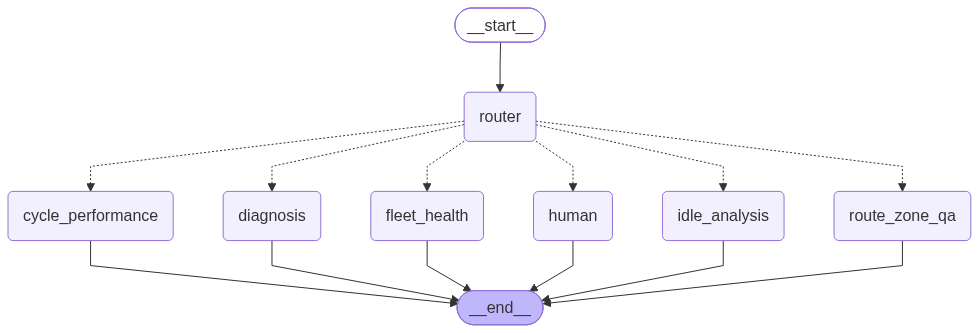

In [12]:
graph = StateGraph(FleetAgentState)
graph.add_node("router", router_node)
graph.add_node("cycle_performance", cycle_performance_node)
graph.add_node("idle_analysis", idle_analysis_node)
graph.add_node("route_zone_qa", route_zone_qa_node)
graph.add_node("fleet_health", fleet_health_node)
graph.add_node("diagnosis", diagnosis_node)
graph.add_node("human", human_node)
graph.set_entry_point("router")
graph.add_conditional_edges(
    "router",
    lambda s: "human" if s["requires_human"] else s["intent"],
    {
        "cycle_performance": "cycle_performance",
        "idle_analysis": "idle_analysis",
        "route_zone_qa": "route_zone_qa",
        "fleet_health": "fleet_health",
        "diagnosis": "diagnosis",
        "human": "human",
    },
)
for node in ["cycle_performance", "idle_analysis", "route_zone_qa", "fleet_health", "diagnosis", "human"]:
    graph.add_edge(node, END)
app = graph.compile()
print("Graph compiled.")

# Real rendering of the compiled graph: PNG via the mermaid.ink API if
# reachable, else a text-only mermaid fallback (never crashes the kernel).
print("\nLangGraph-generated Mermaid diagram:")
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    mermaid_text = app.get_graph().draw_mermaid()
    display(Markdown(f"```\n{mermaid_text}\n```"))

## Section 8 — Demo

Requires `OPENAI_API_KEY` and `data/agent_data/` populated by
`python fleet_agent/preprocessing.py`. Each question defaults to `MONTH` unless the
router finds a date/month/year in the question text, or you pass one to
`ask()` explicitly.

In [13]:
def ask(question: str, date: Optional[str] = None, month: Optional[str] = None,
        year: Optional[str] = None, truck: Optional[str] = None) -> str:
    result = app.invoke({
        "user_input": question, "intent": "",
        "date": date, "month": month, "year": year, "truck": truck,
        "data_context": "", "agent_response": "", "requires_human": False,
    })

    agent_used = "human" if result["requires_human"] else result["intent"]
    period_bits = [f"{k}={result[k]}" for k in ("date", "month", "year", "truck") if result.get(k)]
    period_str = ", ".join(period_bits) if period_bits else f"no period/truck named -> default MONTH={MONTH}"
    header = f"[agent: {agent_used}  |  data: {period_str}]"
    return f"{header}\n{result['agent_response']}"

In [14]:
# → routed to Cycle & Productivity
print(ask("What's the average haul cycle time for the BN trucks?"))

[agent: cycle_performance  |  data: no period/truck named -> default MONTH=2025-11]
The average haul cycle time for the BN trucks is 259.0 minutes.


In [15]:
# → routed to Idle & Stops
print(ask("How much of our fleet time is unplanned idle right now?"))

[agent: idle_analysis  |  data: no period/truck named -> default MONTH=2025-11]
The current unplanned idle time for your fleet is 53.314%.


In [16]:
# → routed to Route & Zone QA
print(ask("Which load/unload routes make up most of the BN cycles this month?"))

[agent: route_zone_qa  |  data: no period/truck named -> default MONTH=2025-11]
Based on the provided data, the load/unload route that makes up most of the BN cycles this month is:

- **Route**: Баруун наран ачилтын бүс /Зүүн/ Баруун наран овоолго
- **Cycles**: 2609
- **Share Percentage**: 100.0%
- **Haul Distance**: 34.55 km

However, there is a zone QA issue to flag:

- **Zone with Zero Stopped Pings**: 
  - **Zone ID**: 27838
  - **Label**: Баруун наран ачилтын бүс /Баруун/
  - **Zone Load Type**: load

This indicates that the zone may have stale or mis-drawn polygons, which could affect the accuracy of the data related to this zone.


In [17]:
# → routed to Fleet Health
print(ask("How many dump trucks vs loaders do we have in the BN fleet?"))

[agent: fleet_health  |  data: no period/truck named -> default MONTH=2025-11]
In the BN fleet, there are 48 dump trucks and 0 loaders, as all 48 trackers are categorized as dump trucks.


In [18]:
# → explicit single-day query, bypassing the router's own date extraction
print(ask("What's the average haul cycle time for the BN trucks?", date="2025-11-03"))

[agent: cycle_performance  |  data: date=2025-11-03]
The average haul cycle time for the BN trucks is 78.8 minutes.


In [19]:
# → per-truck query — the router should pick up "BN70" as the truck slot
# (a real tracker in tracker_list_bn.csv; label "BN70 Howo-430", tracker_id 20505)
print(ask("How's truck BN70 doing this month — cycle times and idle share?"))

[agent: cycle_performance  |  data: truck=BN70]
Truck BN70 has an average cycle time of 331.5 minutes this month. The idle share is not directly provided in the data, but you can analyze the cycle times for trends or outliers if needed.


In [20]:
# → the router should extract date="2025-07-22" straight from the question text
print(ask("On 2025-07-22, how many haul cycles did the BN fleet complete?"))

[agent: cycle_performance  |  data: date=2025-07-22, month=2025-07, year=2025]
The BN fleet completed 61 haul cycles on 2025-07-22.


In [21]:
# → per-truck, per-month breakdown — truck="EACH" forces every BN truck's own
# row instead of the fleet-wide "ALL" one; year="2025" pulls monthly_2025.csv
# (one row per (month, tracker_id)) instead of a single month's daily table.
print(ask("For each technic, how many cycles did it do per month?", year="2025", truck="EACH"))

[agent: cycle_performance  |  data: year=2025, truck=EACH]
Here are the cycle counts for each truck per month:

**July 2025:**
- BN70 Howo-430: 141 cycles
- BN71 Howo-430: 92 cycles
- BN69 Howo-430: 173 cycles
- BN97 /67-87УЕК/: 90 cycles
- BN117 /71-23 УНТ/: 90 cycles
- BN137 /69-71УЕУ/: 138 cycles
- BN144 /73-96 УКА/: 193 cycles
- BN142 /73-94 УКА/: 99 cycles
- BN143 /73-95 УКО/: 181 cycles
- BN145 / 71-23 УКО: 125 cycles
- BN147 / 41-90 УНК: 86 cycles
- BN146 / 73-99 ХӨН: 92 cycles
- #BN149 83-64 УКО: 111 cycles

**August 2025:**
- BN70 Howo-430: 172 cycles
- BN71 Howo-430: 98 cycles
- BN69 Howo-430: 157 cycles
- BN97 /67-87УЕК/: 117 cycles
- BN117 /71-23 УНТ/: 9 cycles
- BN137 /69-71УЕУ/: 158 cycles
- BN144 /73-96 УКА/: 187 cycles
- BN142 /73-94 УКА/: 197 cycles
- BN143 /73-95 УКО/: 191 cycles
- BN145 / 71-23 УКО: 72 cycles
- BN147 / 41-90 УНК: 71 cycles
- BN146 / 73-99 ХӨН: 87 cycles
- #BN149 83-64 УКО: 94 cycles
- BN150 / 71-23 ХӨН: 153 cycles
- BN153 69-93 УНЭ: 91 cycles
- BN156

In [22]:

print(ask("For each technic, how many cycles they are doing per day?", year="2025", truck="EACH"))

[agent: cycle_performance  |  data: year=2025, truck=EACH]
The overall average number of cycles per day across the fleet is 12443 cycles. 

For specific trucks, the daily cycle counts can be derived from the per-month breakdown data, but the overall average is already provided. If you need details for specific trucks or trends, please let me know!


In [23]:
print(ask("What can be done to improve efficiency?", year="2025"))

[agent: diagnosis  |  data: year=2025]
The VERDICT indicates that the Queue at Баруун наран пүү/Ухаа/ + БН-Хучлаг авах цэг and Stopped at places several trucks share that have no polygon are TIED for first priority. 

The fleet averaged 82.3 loads per day over 153 days, with a range of 13-26 trucks and an average cycle time of 313.3 minutes. 

The two joint-first levers are:
1. Queue at Баруун наран пүү/Ухаа/ + БН-Хучлаг авах цэг: +7.6 loads/day, 5534 truck-h/yr
2. Stopped at places several trucks share that have no polygon: +4.9 loads/day, 3722 truck-h/yr

In addition, there are 8 further buckets that collectively account for +2.4 down to +0.2 loads/day, totaling 8333 truck-h/yr between them.

The leading lever held first place in 4 of the 5 months, indicating a consistent issue that requires attention. 

One thing we cannot explain is the stoppage at places several trucks share that have no polygon, which accounted for 3722 truck-h across the year. The coordinates of the most signifi

In [24]:
print(ask("What can be done to improve efficiency?", month="2025-10"))

[agent: diagnosis  |  data: month=2025-10]
The first priority for improving efficiency is the tied issues of stopping at places several trucks share that have no polygon and queueing at Баруун наран пүү/Ухаа/ + БН-Хучлаг авах цэг. 

The fleet experienced 98.9 loads/day from 26 trucks over 31 days, with 8 further buckets contributing a combined total of 2279 truck-hours per month and an additional +4.1 to +0.2 loads/day each. 

One thing we cannot explain is the stopping at places several trucks share that have no polygon, which accounted for 1098 truck-hours. The largest instances were: 190 truck-hours with 8 different trucks at coordinates 43.68683, 105.5558; 160 truck-hours with 25 different trucks at 43.65425, 105.50633; and 147 truck-hours with 26 different trucks at 43.6816, 105.34777. What is at these coordinates? 

Gains are an upper bound on what a cause is worth, not a forecast; there is no payload data, so we speak in loads and truck-hours; this is a diagnostic, not proof, an